# IY023: Batch-wise Normalisation + Mixed Dataset Visualisation

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from dataloaders.simclr import ssl_data_prep
from stats.autocorrelation import calculate_autocorrelation, calculate_ac_time_interp1d
%load_ext autoreload
%autoreload 2

## Load mixed data sources (same 4 as `IY023_simclr_training_mixed.py`)

In [2]:
EXP_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020")

DATA_SOURCES = [
    (EXP_ROOT / "data",               "IY020_simulation_parameters_sobol.csv"),
    (EXP_ROOT / "data_mu_variation",  "IY020_simulation_mu_parameters_sobol.csv"),
    (EXP_ROOT / "data_cv_variation",  "IY020_simulation_cv_parameters_sobol.csv"),
    (EXP_ROOT / "data_t_ac_variation","IY020_simulation_t_ac_parameters_sobol.csv"),
]

TRAJ_PATH = []
for data_root, results_csv in DATA_SOURCES:
    df = pd.read_csv(data_root / results_csv)
    df = df[(df['success'] == True) &
            (df['error_message'].isna()) &
            (df['mean_rel_error_pct'] < 10) &
            (df['cv_rel_error_pct'] < 10) &
            (df['t_ac_rel_error_pct'] < 10)]
    paths = [data_root / df['trajectory_filename'].values[i] for i in range(len(df))]
    TRAJ_PATH.extend(paths)
    print(f"  {data_root.name}: {len(paths)} trajectories")

print(f"Total trajectories: {len(TRAJ_PATH)}")

  data: 7709 trajectories
  data_mu_variation: 9997 trajectories
  data_cv_variation: 9699 trajectories
  data_t_ac_variation: 9660 trajectories
Total trajectories: 37065


## Build dataloader with `batch-wise` normalisation

In [3]:
batch_size = 64
num_traj = 1
sample_len = 500
log_scale = False
normalisation = 'batch-wise'

train_loader, val_loader, test_loader = ssl_data_prep(
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)

X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape)  # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 500, 1]) torch.Size([64, 500, 1]) torch.Size([64, 1])


## Visualisation helper

In [4]:
def visualize_loader_samples(loader, loader_name, num_samples=3):
    """
    Visualizes samples from the dataloader including Mean, CV and AC time statistics.
    """
    if not loader:
        print(f"{loader_name} is None or empty.")
        return

    batch = next(iter(loader))

    if len(batch) == 3:
        X1, X2, y = batch
        has_two_views = True
        print(f"--- {loader_name} (SSL Pairs) ---")
        print(f"Shapes :: X1: {X1.shape}, X2: {X2.shape}, y: {y.shape}")
    elif len(batch) == 2:
        X1, y = batch
        X2 = None
        has_two_views = False
        print(f"--- {loader_name} (Standard) ---")
        print(f"Shapes :: X: {X1.shape}, y: {y.shape}")
    else:
        print(f"Unexpected batch format length: {len(batch)}")
        return

    cols = 2 if has_two_views else 1
    fig, axes = plt.subplots(num_samples, cols, figsize=(12, 3.5 * num_samples), squeeze=False)

    for i in range(min(num_samples, len(X1))):
        label_str = f"{y[i].item():.4f}" if y[i].numel() == 1 else "Vector"

        x1_data = X1[i].flatten().cpu().numpy()
        mu1, std1 = np.mean(x1_data), np.std(x1_data)
        cv1 = std1 / abs(mu1) if abs(mu1) > 1e-5 else 0
        autocorr_results1 = calculate_autocorrelation(x1_data)
        ac_mean1 = autocorr_results1["stress_ac"].mean(axis=0)
        lags1 = autocorr_results1["stress_lags"]
        ac_time_observed1 = calculate_ac_time_interp1d(ac_mean1, lags1)

        ax1 = axes[i, 0]
        ax1.plot(x1_data, color='tab:blue', alpha=0.8)
        ax1.set_title(f"Sample {i} - View 1 (y={label_str})\nMean={abs(mu1):.2f}, CV={abs(cv1):.2f}, AC Time={ac_time_observed1:.2f}")
        ax1.set_xlabel("Time")
        ax1.set_ylabel("Signal")
        ax1.grid(True, alpha=0.3)

        if has_two_views:
            x2_data = X2[i].flatten().cpu().numpy()
            mu2, std2 = np.mean(x2_data), np.std(x2_data)
            cv2 = std2 / abs(mu2) if abs(mu2) > 1e-5 else 0
            autocorr_results2 = calculate_autocorrelation(x2_data)
            ac_mean2 = autocorr_results2["stress_ac"].mean(axis=0)
            lags2 = autocorr_results2["stress_lags"]
            ac_time_observed2 = calculate_ac_time_interp1d(ac_mean2, lags2)

            ax2 = axes[i, 1]
            ax2.plot(x2_data, color='tab:orange', alpha=0.8)
            ax2.set_title(f"Sample {i} - View 2\nMean={abs(mu2):.2f}, CV={abs(cv2):.2f}, AC Time={ac_time_observed2:.2f}")
            ax2.set_xlabel("Time")
            ax2.grid(True, alpha=0.3)

    fig.suptitle(f"{loader_name} | normalisation='{normalisation}' | sample_len={sample_len}", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## Train loader

--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 500, 1]), X2: torch.Size([64, 500, 1]), y: torch.Size([64, 1])


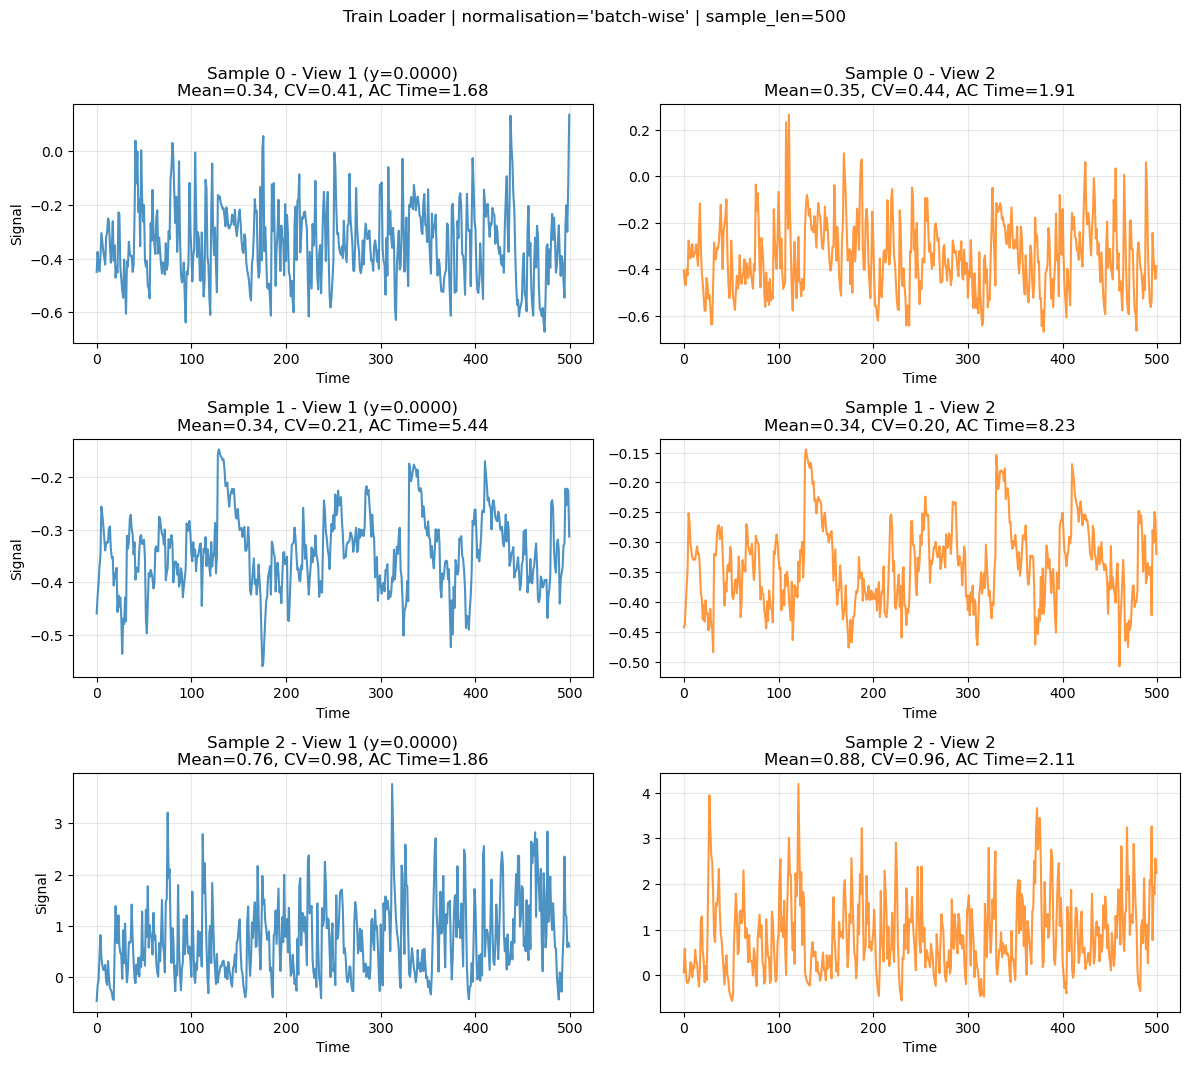

In [5]:
visualize_loader_samples(train_loader, "Train Loader")

## Validation loader

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 500, 1]), X2: torch.Size([64, 500, 1]), y: torch.Size([64, 1])


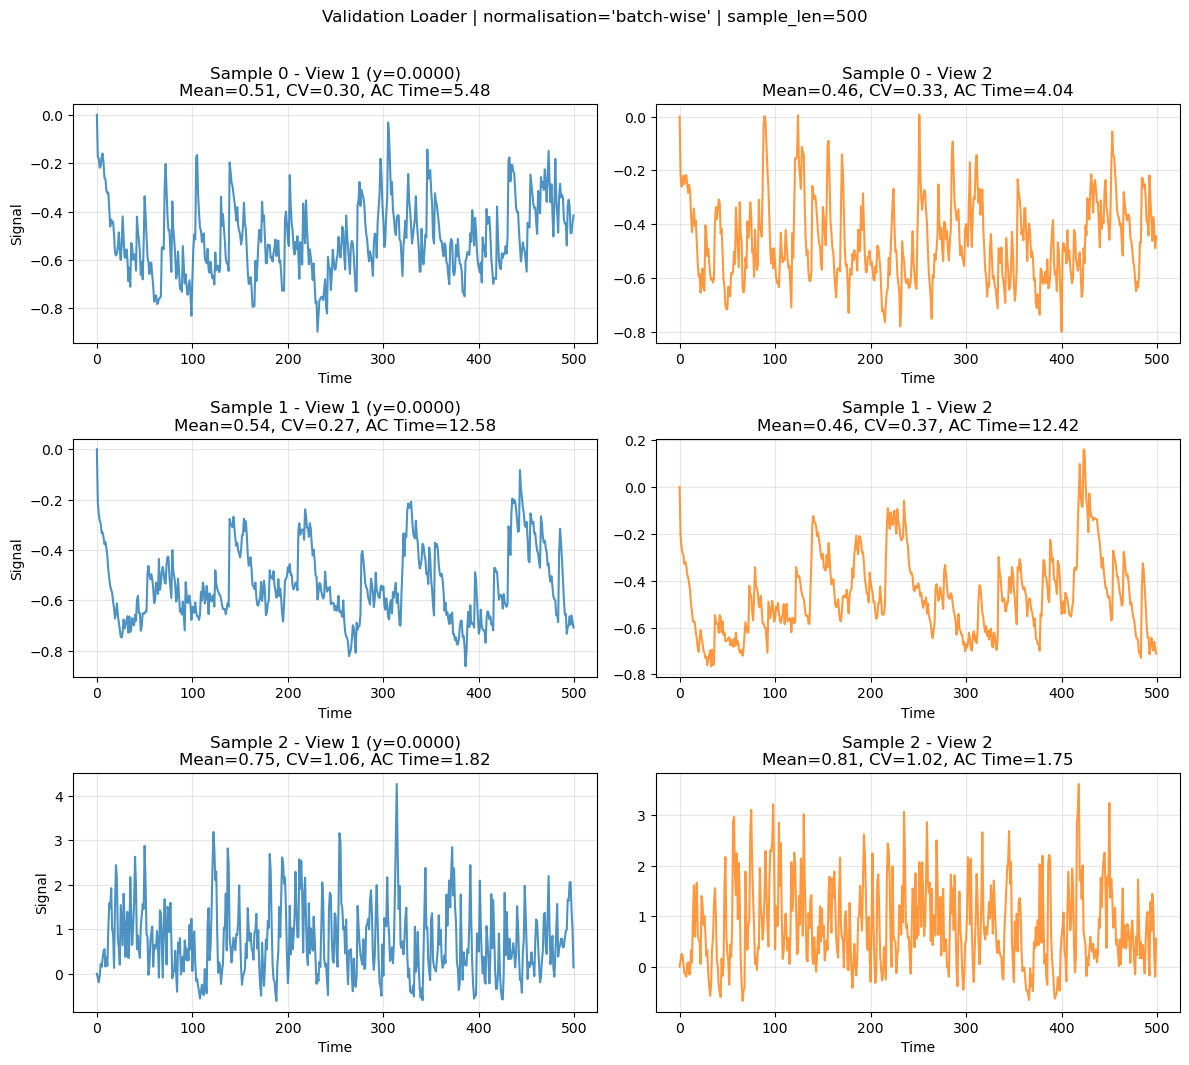

In [6]:
visualize_loader_samples(val_loader, "Validation Loader")

## Test loader

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 500, 1]), X2: torch.Size([64, 500, 1]), y: torch.Size([64, 1])


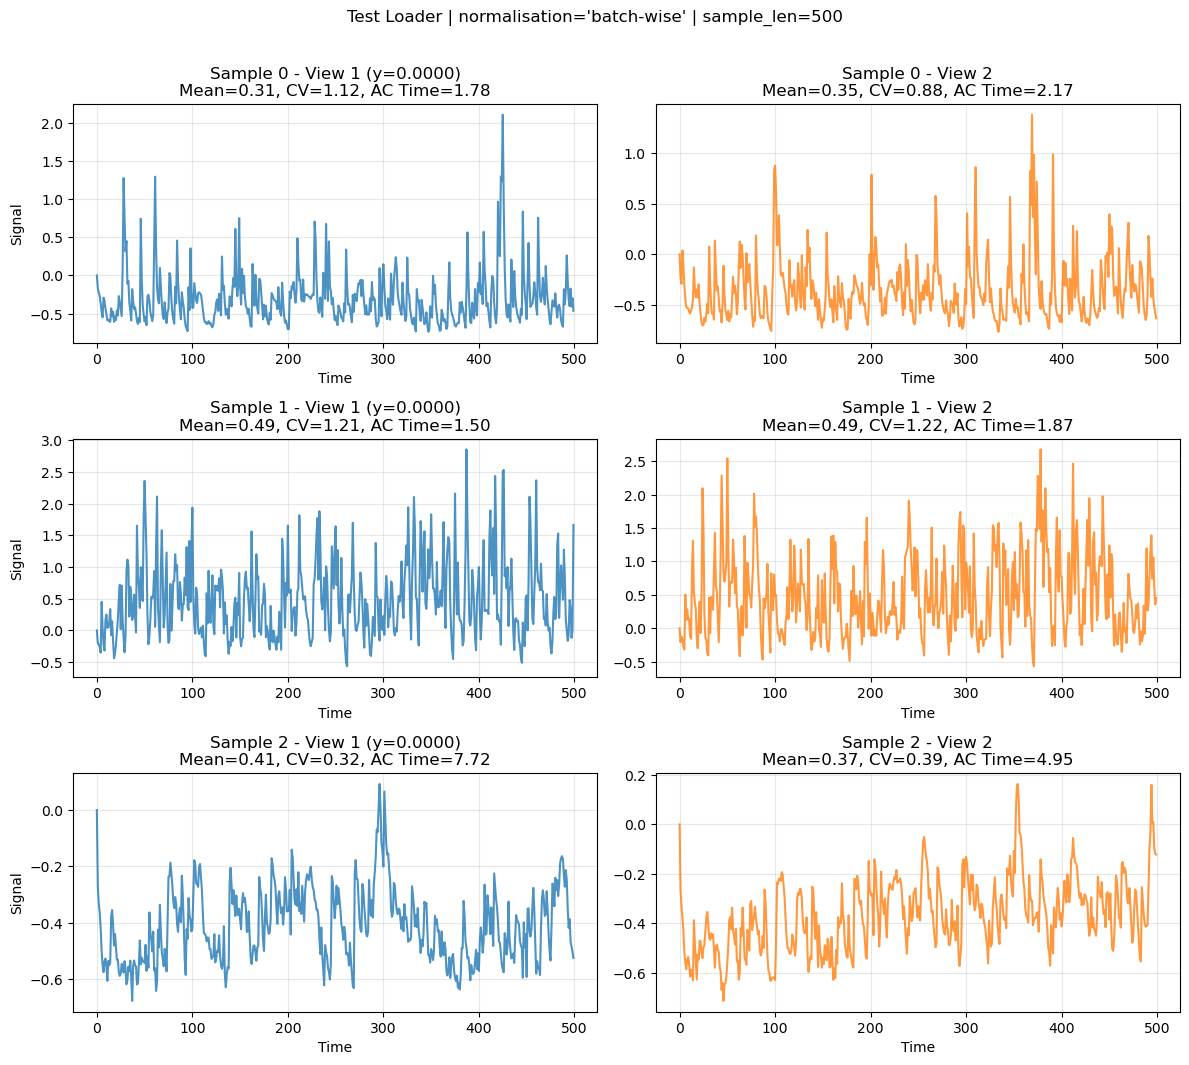

In [7]:
visualize_loader_samples(test_loader, "Test Loader")

---
# Global Normalisation

In [8]:
batch_size = 64
num_traj = 1
sample_len = 500
log_scale = False
normalisation = 'global'

train_loader, val_loader, test_loader = ssl_data_prep(
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)

X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape)  # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 500, 1]) torch.Size([64, 500, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 500, 1]), X2: torch.Size([64, 500, 1]), y: torch.Size([64, 1])


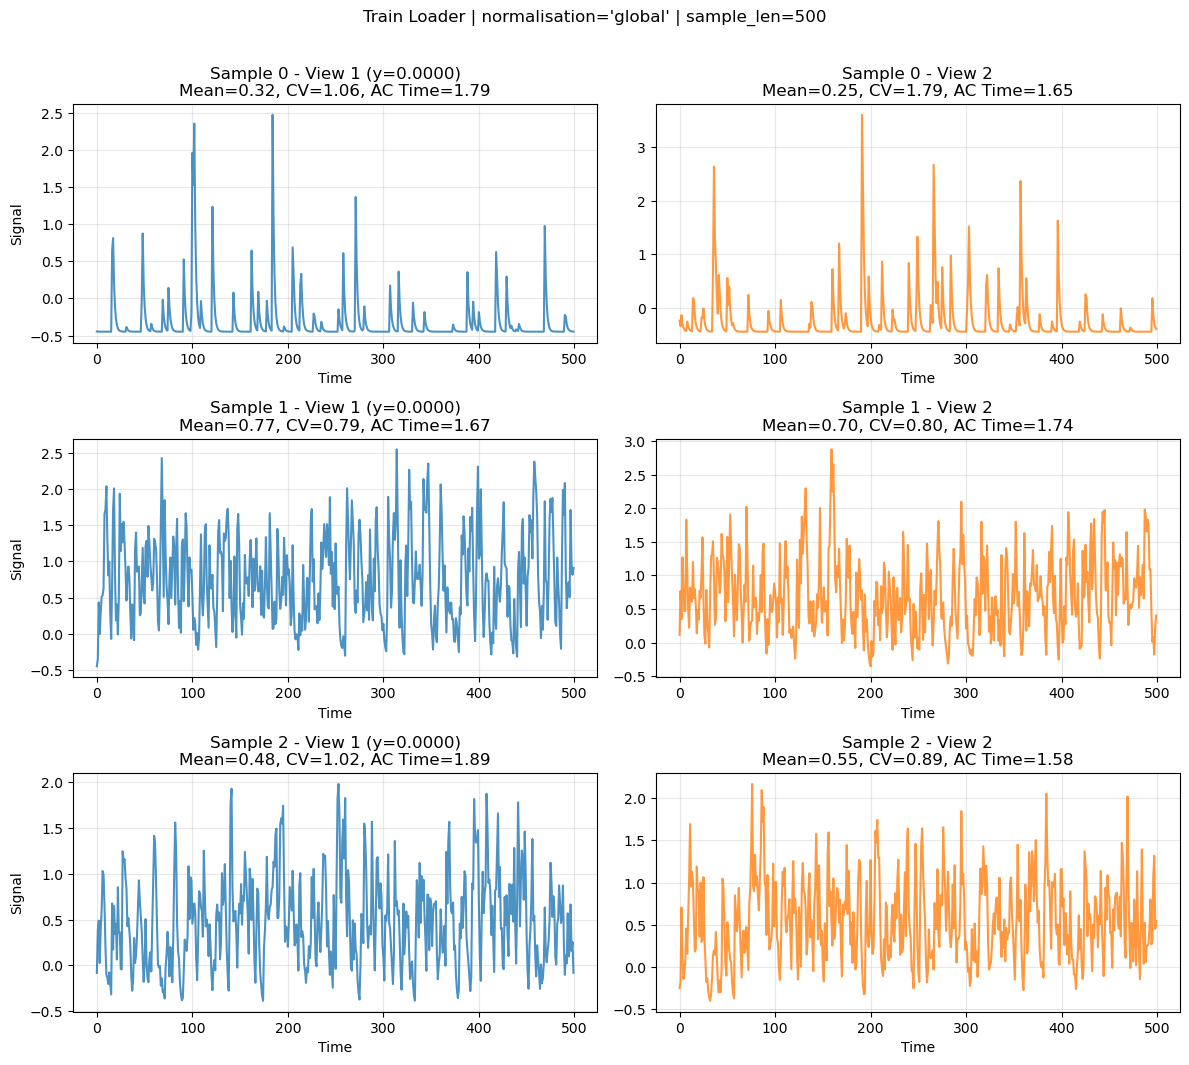

In [9]:
visualize_loader_samples(train_loader, "Train Loader")